Cell 1 — Imports and path setup

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from pathlib import Path

# so Python can find your src/ modules
sys.path.append(str(Path("../src/physics").resolve()))

from heat_solver import make_grid, gaussian_hotspot, run_simulation, compute_stable_dt
from boundary_conditions import apply_dirichlet_zero

%matplotlib inline

Cell 2 — Run a basic simulation

In [2]:
# --- configuration ---
N     = 64       # grid points per side
L     = 1.0      # domain size
alpha = 0.01     # thermal diffusivity

x, y, dx = make_grid(N, L)

# single Gaussian hot blob at center
T0 = gaussian_hotspot(x, y, cx=0.5, cy=0.5, sigma=0.08, amplitude=1.0)

# run for 500 steps, save every 50
snapshots, times, dt, r = run_simulation(
    T0, alpha, dx, n_steps=500, save_every=50
)

print(f"\nSnapshots shape: {snapshots.shape}")   # expect (11, 64, 64)
print(f"Times:           {np.round(times, 4)}")

Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 2.8345

Snapshots shape: (11, 64, 64)
Times:           [0.     0.2834 0.5669 0.8503 1.1338 1.4172 1.7007 1.9841 2.2676 2.551
 2.8345]


Cell 3 — Visualize the evolution

C:\Users\adity\AppData\Local\Temp\ipykernel_51608\3886392927.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


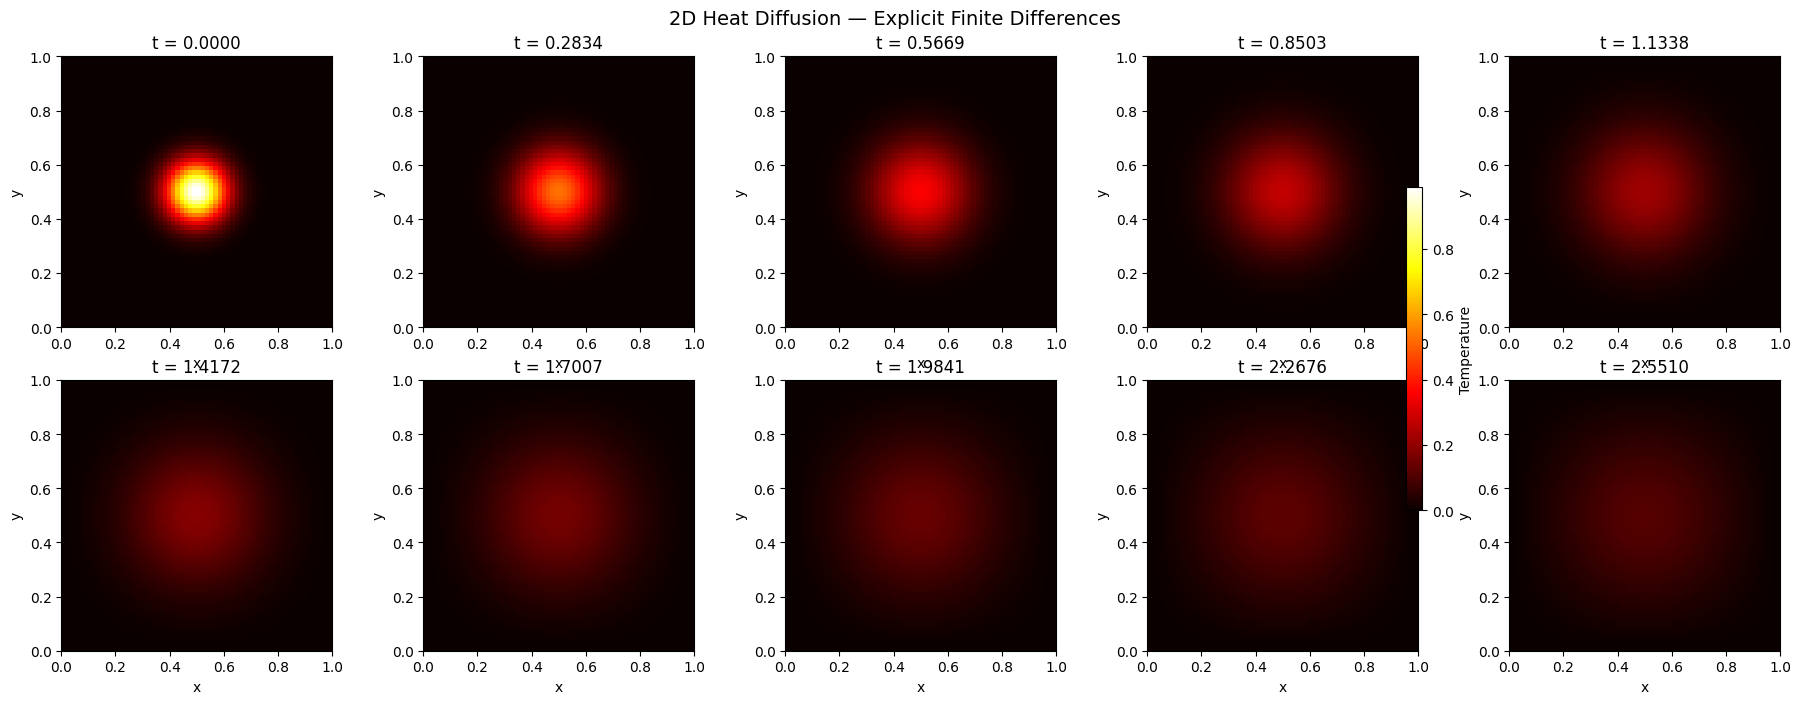

Figure saved to figures/milestone2_evolution.png


In [3]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

# use a fixed color scale across ALL panels — critical for honest comparison
vmin = snapshots.min()
vmax = snapshots.max()

for i, ax in enumerate(axes):
    im = ax.imshow(
        snapshots[i],
        origin="lower",
        extent=[0, L, 0, L],
        cmap="hot",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f"t = {times[i]:.4f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.colorbar(im, ax=axes, shrink=0.6, label="Temperature")
fig.suptitle("2D Heat Diffusion — Explicit Finite Differences", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/milestone2_evolution.png", dpi=150)
plt.show()

print("Figure saved to figures/milestone2_evolution.png")

Cell 4 — Validation test 1: total energy should decrease monotonically (Dirichlet BC)

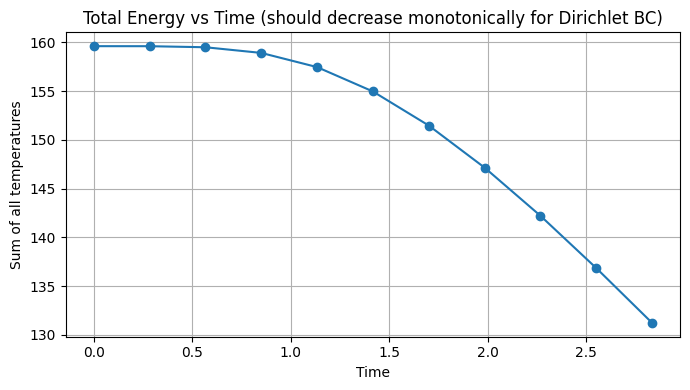

✓ Energy decreases monotonically. Dirichlet BC is working correctly.


In [4]:
total_energy = snapshots.sum(axis=(1, 2))

plt.figure(figsize=(7, 4))
plt.plot(times, total_energy, marker="o")
plt.xlabel("Time")
plt.ylabel("Sum of all temperatures")
plt.title("Total Energy vs Time (should decrease monotonically for Dirichlet BC)")
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/milestone2_energy.png", dpi=150)
plt.show()

# assertion: energy should be strictly decreasing
diffs = np.diff(total_energy)
assert np.all(diffs < 0), "Energy increased at some step — check your solver!"
print("✓ Energy decreases monotonically. Dirichlet BC is working correctly.")

Cell 5 — Validation test 2: no NaNs or infinities

In [5]:
for i, snap in enumerate(snapshots):
    assert not np.any(np.isnan(snap)),  f"NaN detected at snapshot {i} (t={times[i]:.4f})"
    assert not np.any(np.isinf(snap)),  f"Inf detected at snapshot {i} (t={times[i]:.4f})"

print(f"✓ No NaN or Inf values found across {len(snapshots)} snapshots.")
print(f"  Temperature range: [{snapshots.min():.6f}, {snapshots.max():.6f}]")
print(f"  Max temperature should be <= initial max ({T0.max():.4f})")
assert snapshots.max() <= T0.max() + 1e-10, "Temperature exceeded initial maximum — unphysical!"
print("✓ Maximum temperature never exceeds initial maximum.")

✓ No NaN or Inf values found across 11 snapshots.
  Temperature range: [0.000000, 0.990206]
  Max temperature should be <= initial max (0.9902)
✓ Maximum temperature never exceeds initial maximum.


Cell 6 — Validation test 3: what happens if you violate the stability condition

In [6]:
# deliberately choose an unstable dt
dx_test   = 1.0 / (64 - 1)
alpha_test = 0.01
dt_bad    = 0.5 * dx_test**2 / alpha_test   # this gives r = 2.0, far above 0.25

r_bad = alpha_test * dt_bad / dx_test**2
print(f"Unstable Fourier number r = {r_bad:.4f}  (should be > 0.25)")

T_bad = gaussian_hotspot(x, y)
for step_num in range(20):
    T_new = T_bad.copy()
    T_new[1:-1, 1:-1] = (
        T_bad[1:-1, 1:-1]
        + r_bad * (
            T_bad[2:,   1:-1]
          + T_bad[:-2,  1:-1]
          + T_bad[1:-1, 2:]
          + T_bad[1:-1, :-2]
          - 4 * T_bad[1:-1, 1:-1]
        )
    )
    T_bad = T_new
    if np.any(np.isnan(T_bad)) or np.any(np.isinf(T_bad)):
        print(f"✓ Instability confirmed: NaN/Inf appeared at step {step_num + 1}")
        break
    if T_bad.max() > 1e6:
        print(f"✓ Instability confirmed: values exploded to {T_bad.max():.2e} at step {step_num + 1}")
        break

Unstable Fourier number r = 0.5000  (should be > 0.25)


Cell 7 — Validation test 4: higher alpha diffuses faster

Grid spacing     dx = 0.015873
Time step        dt = 0.056689
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 11.3379
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 1.1338
Grid spacing     dx = 0.015873
Time step        dt = 0.001134
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.2268


C:\Users\adity\AppData\Local\Temp\ipykernel_51608\313769337.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


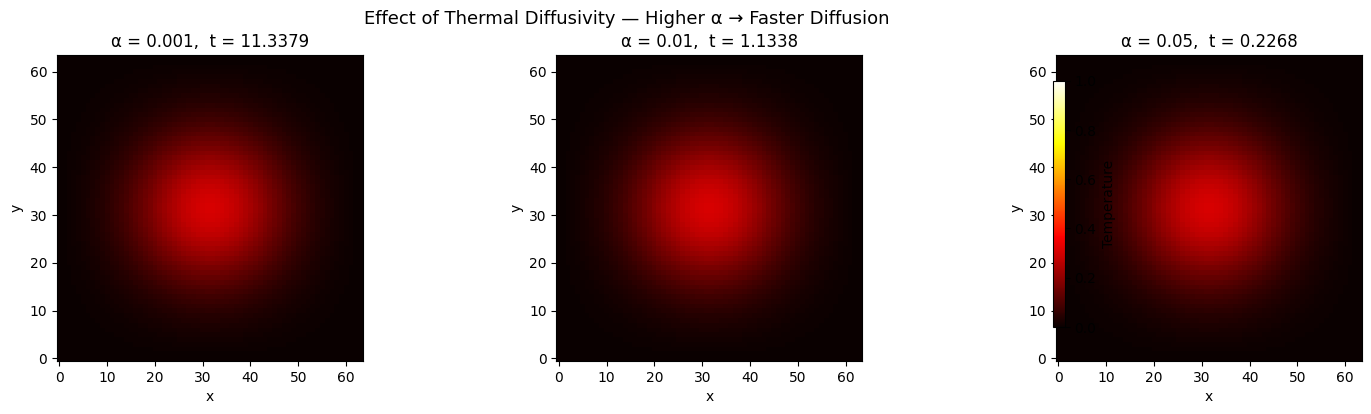

✓ Higher alpha visibly produces more diffusion in the same number of steps.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
alphas = [0.001, 0.01, 0.05]

for ax, a in zip(axes, alphas):
    x_, y_, dx_ = make_grid(64)
    T0_ = gaussian_hotspot(x_, y_)
    snaps, times_, _, _ = run_simulation(T0_, a, dx_, n_steps=200, save_every=200)
    
    im = ax.imshow(snaps[-1], origin="lower", cmap="hot", vmin=0, vmax=1)
    ax.set_title(f"α = {a},  t = {times_[-1]:.4f}")
    ax.set_xlabel("x"); ax.set_ylabel("y")

fig.colorbar(im, ax=axes, shrink=0.8, label="Temperature")
fig.suptitle("Effect of Thermal Diffusivity — Higher α → Faster Diffusion", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/milestone2_alpha_comparison.png", dpi=150)
plt.show()
print("✓ Higher alpha visibly produces more diffusion in the same number of steps.")